#### Importing Necessary Libraries

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

#### Load Excel into DataFrame

In [75]:
df = pd.read_excel("data/premiums_young.xlsx")
rows, col = df.shape
print(f"Total number of rows are {rows} and columns are {col}")

Total number of rows are 20096 and columns are 13


In [76]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,20096.000000,20096.000000,20096.000000,20096.000000
mean,21.494029,0.718004,22.506519,8141.941033
std,2.294050,0.940767,23.418644,2749.609551
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.000000
50%,21.500000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


In [77]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [78]:
df.columns = df.columns.str.lower().str.replace(" ","_")
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

#### Treating Null Values

In [79]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [80]:
df = df.dropna() 
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

#### Treating Duplicates Rows

In [81]:
df.duplicated().sum()
df = df.drop_duplicates()

#### Treating Outliers

In [82]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267
std,2.294052,0.940713,23.420493,2749.906347
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


In [83]:
df[df.number_of_dependants<0].shape

(22, 13)

In [84]:
df['number_of_dependants'] = df['number_of_dependants'].abs()
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.722598,22.510851,8142.096267
std,2.294052,0.937200,23.420493,2749.906347
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


#### Boxplot for Numeric Columns

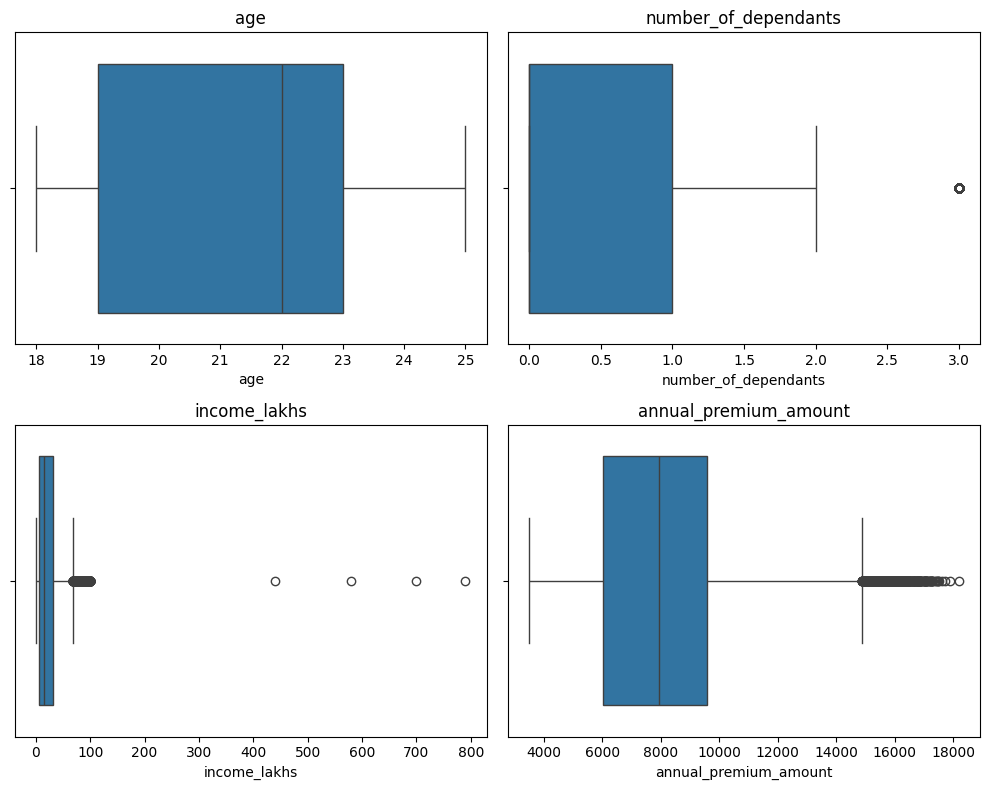

In [85]:
numeric_col = df.select_dtypes(include='number').columns
n_cols = 2  # Number of plots per row
n_rows = math.ceil(len(numeric_col) / n_cols)

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(numeric_col, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### Histogram for Income column

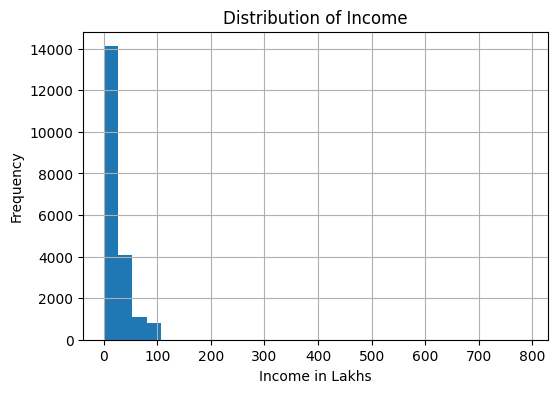

In [86]:
df['income_lakhs'].hist(bins=30, figsize=(6,4))
plt.title("Distribution of Income")
plt.xlabel("Income in Lakhs")
plt.ylabel("Frequency")
plt.show()

#### Outlier Removal using IQR

In [87]:
def iqr_cal(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [88]:
upper, lower = iqr_cal('income_lakhs')
print(upper, lower)

-31.5 68.5


In [89]:
quantile_threshold = df.income_lakhs.quantile(0.999)
quantile_threshold

np.float64(100.0)

In [90]:
df = df[df['income_lakhs']<quantile_threshold]
df[df['income_lakhs']>100]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount


#### Histogram for Numeric Columns

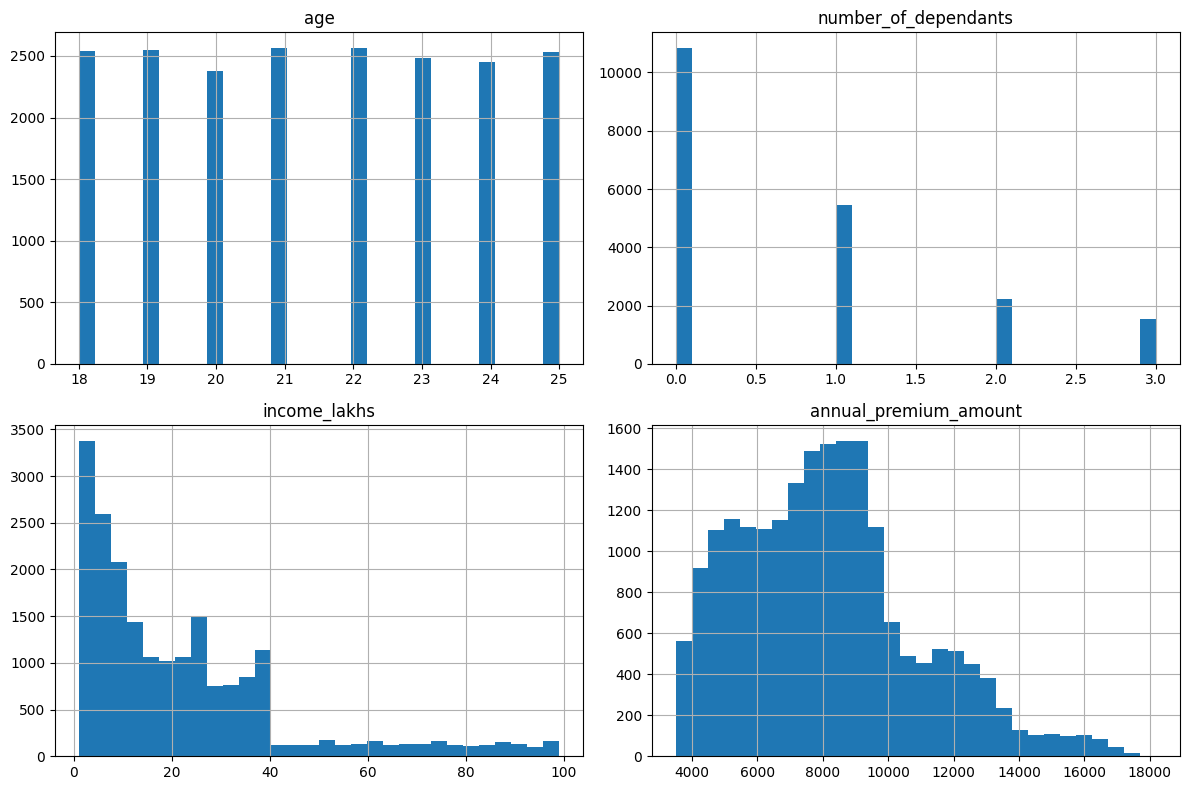

In [91]:
df.hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

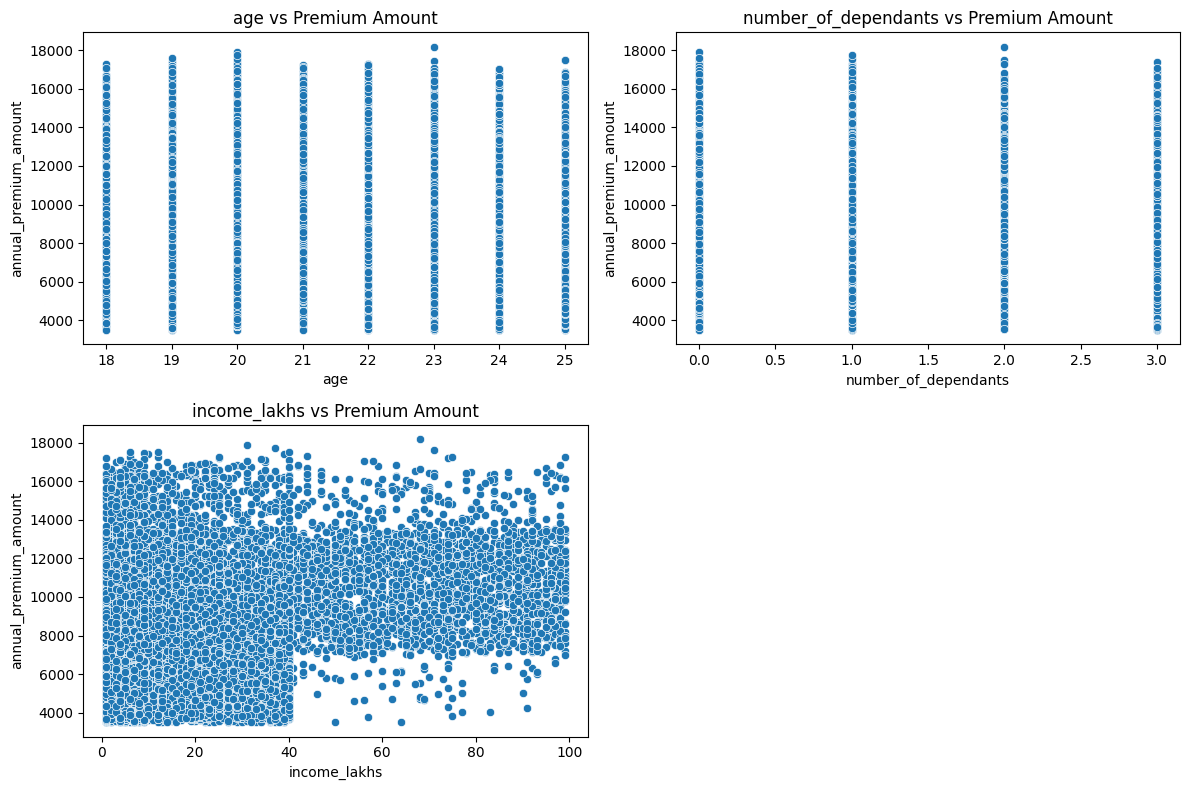

In [92]:
# num_col = numeric_col
num_col = numeric_col.drop('annual_premium_amount')  # remove target

n_cols = 2
n_rows = math.ceil(len(num_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.scatterplot(x=df[col], y=df['annual_premium_amount'], ax=axes[i])
    axes[i].set_title(f"{col} vs Premium Amount")

# Remove extra empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Outlier Removal in Categorical Column

In [93]:
cat_col = df.select_dtypes(include='object').columns
cat_col

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [94]:
for col in cat_col:
    print(f"{col}:{df[col].unique()}")

gender:['Male' 'Female']
region:['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status:['Unmarried' 'Married']
bmi_category:['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status:['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status:['Self-Employed' 'Freelancer' 'Salaried']
income_level:['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history:['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan:['Silver' 'Bronze' 'Gold']


In [95]:
df['smoking_status'] = df['smoking_status'].replace(
    ['Smoking=0', 'Does Not Smoke', 'Not Smoking'],
    'No Smoking')

In [96]:
for col in cat_col:
    print(f"{col}:{df[col].unique()}")

gender:['Male' 'Female']
region:['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status:['Unmarried' 'Married']
bmi_category:['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status:['Regular' 'No Smoking' 'Occasional']
employment_status:['Self-Employed' 'Freelancer' 'Salaried']
income_level:['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history:['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan:['Silver' 'Bronze' 'Gold']


In [97]:
df['gender'].value_counts()

gender
Male      11037
Female     9017
Name: count, dtype: int64

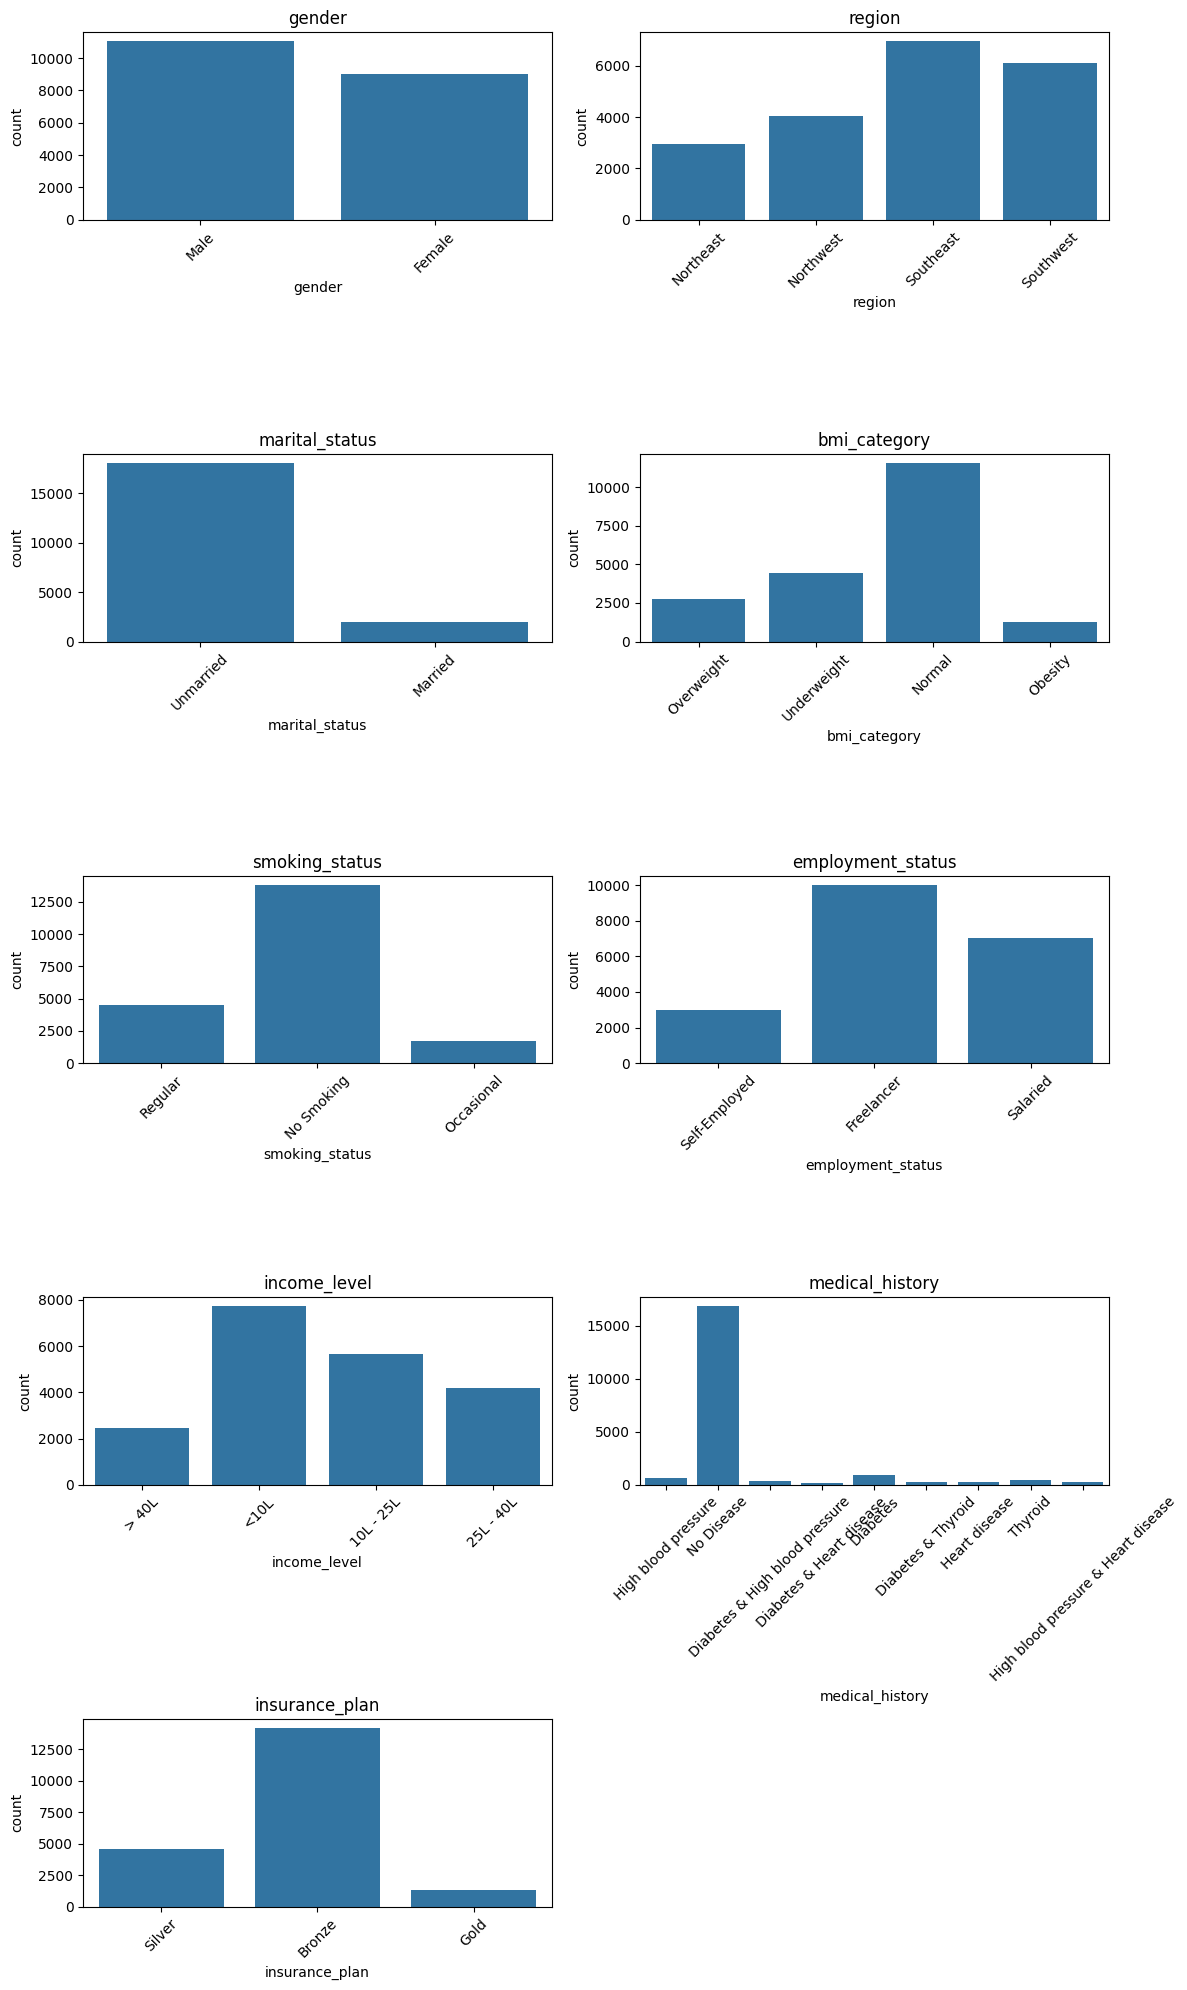

In [98]:
n_cols = 2
n_rows = math.ceil(len(cat_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove extra empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Bi-Variate Analysis

In [99]:
pd.crosstab(df['income_level'], df['insurance_plan'])

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,4508,326,828
25L - 40L,3382,209,608
<10L,6172,404,1145
> 40L,115,362,1995


#### Feature Engineering

In [100]:
df.medical_history.unique()

array(['High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Diabetes & Heart disease',
       'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid',
       'High blood pressure & Heart disease'], dtype=object)

In [101]:
risk_scores = {
    'diabetes':6,
    'heart disease':8,
    'high blood pressure':6,
    'no disease':0,
    'thyroid':5,
    'none':0
}

In [102]:
df[['disease1','disease2']] = df['medical_history'].str.split("&", expand=True).apply(lambda x:x.str.lower().str.strip())

In [103]:
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,high blood pressure,None
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,no disease,None
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,no disease,None
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,no disease,None
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,no disease,None


In [104]:
df['disease1'].fillna('none', inplace=True)
df['disease2'].fillna('none', inplace=True)
df.head()
invalid_rows = df[~df['disease1'].isin(risk_scores.keys())]
invalid_rows

C:\Users\yogesh\AppData\Local\Temp\ipykernel_10352\3574473948.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['disease1'].fillna('none', inplace=True)
C:\Users\yogesh\AppData\Local\Temp\ipykernel_10352\3574473948.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2


In [105]:
df['total_risk_score'] = 0

for disease in ['disease1','disease2']:
    df['total_risk_score'] += df[disease].map(risk_scores)
max_score = df['total_risk_score'].max()
min_score = df['total_risk_score'].min()
df['normalized_risk_score'] = (df['total_risk_score'] - min_score )/(max_score - min_score)
df.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
5465,18,Male,Southeast,Unmarried,2,Normal,No Smoking,Freelancer,10L - 25L,18,No Disease,Bronze,6080,no disease,none,0,0.000000
13872,22,Male,Southwest,Married,3,Overweight,No Smoking,Salaried,25L - 40L,40,No Disease,Silver,12013,no disease,none,0,0.000000
9273,25,Male,Southwest,Married,3,Normal,No Smoking,Salaried,10L - 25L,15,No Disease,Bronze,7387,no disease,none,0,0.000000
4583,23,Female,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,10,No Disease,Bronze,8323,no disease,none,0,0.000000
14057,24,Male,Southeast,Unmarried,0,Overweight,No Smoking,Salaried,10L - 25L,16,Diabetes & Thyroid,Bronze,5903,diabetes,thyroid,11,0.785714


In [106]:
df.insurance_plan.unique()

array(['Silver', 'Bronze', 'Gold'], dtype=object)

In [107]:
df['insurance_plan'] = df['insurance_plan'].map({'Bronze':1, 'Silver':2, 'Gold':3})
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,2,13365,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,2,11050,no disease,none,0,0.000000
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,2,11857,no disease,none,0,0.000000
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,1,5684,no disease,none,0,0.000000
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,1,5712,no disease,none,0,0.000000


In [108]:
df.insurance_plan.unique()

array([2, 1, 3])

In [109]:
df['income_level'].unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L'], dtype=object)

In [110]:
df['income_level'] = df['income_level'].map({'<10L':1, '10L - 25L':2, '> 40L':4, '25L - 40L':3})
df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,4,99,High blood pressure,2,13365,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,1,3,No Disease,2,11050,no disease,none,0,0.000000


In [111]:
df['income_level'].unique()

array([4, 1, 2, 3])

In [112]:
nominal_cols = ['gender','region','marital_status','bmi_category','smoking_status','employment_status']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)
df.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,high blood pressure,none,6,...,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,No Disease,2,11050,no disease,none,0,...,0,0,1,0,0,1,0,0,0,0
2,21,0,4,97,No Disease,2,11857,no disease,none,0,...,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,No Disease,1,5684,no disease,none,0,...,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,No Disease,1,5712,no disease,none,0,...,1,0,1,0,1,0,0,0,0,0


In [113]:
df = df.drop(['medical_history','disease1','disease2','total_risk_score'],axis=1)

In [114]:
df.head(2)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,0.000000,0,1,0,0,1,0,0,1,0,0,0,0


#### Correlation

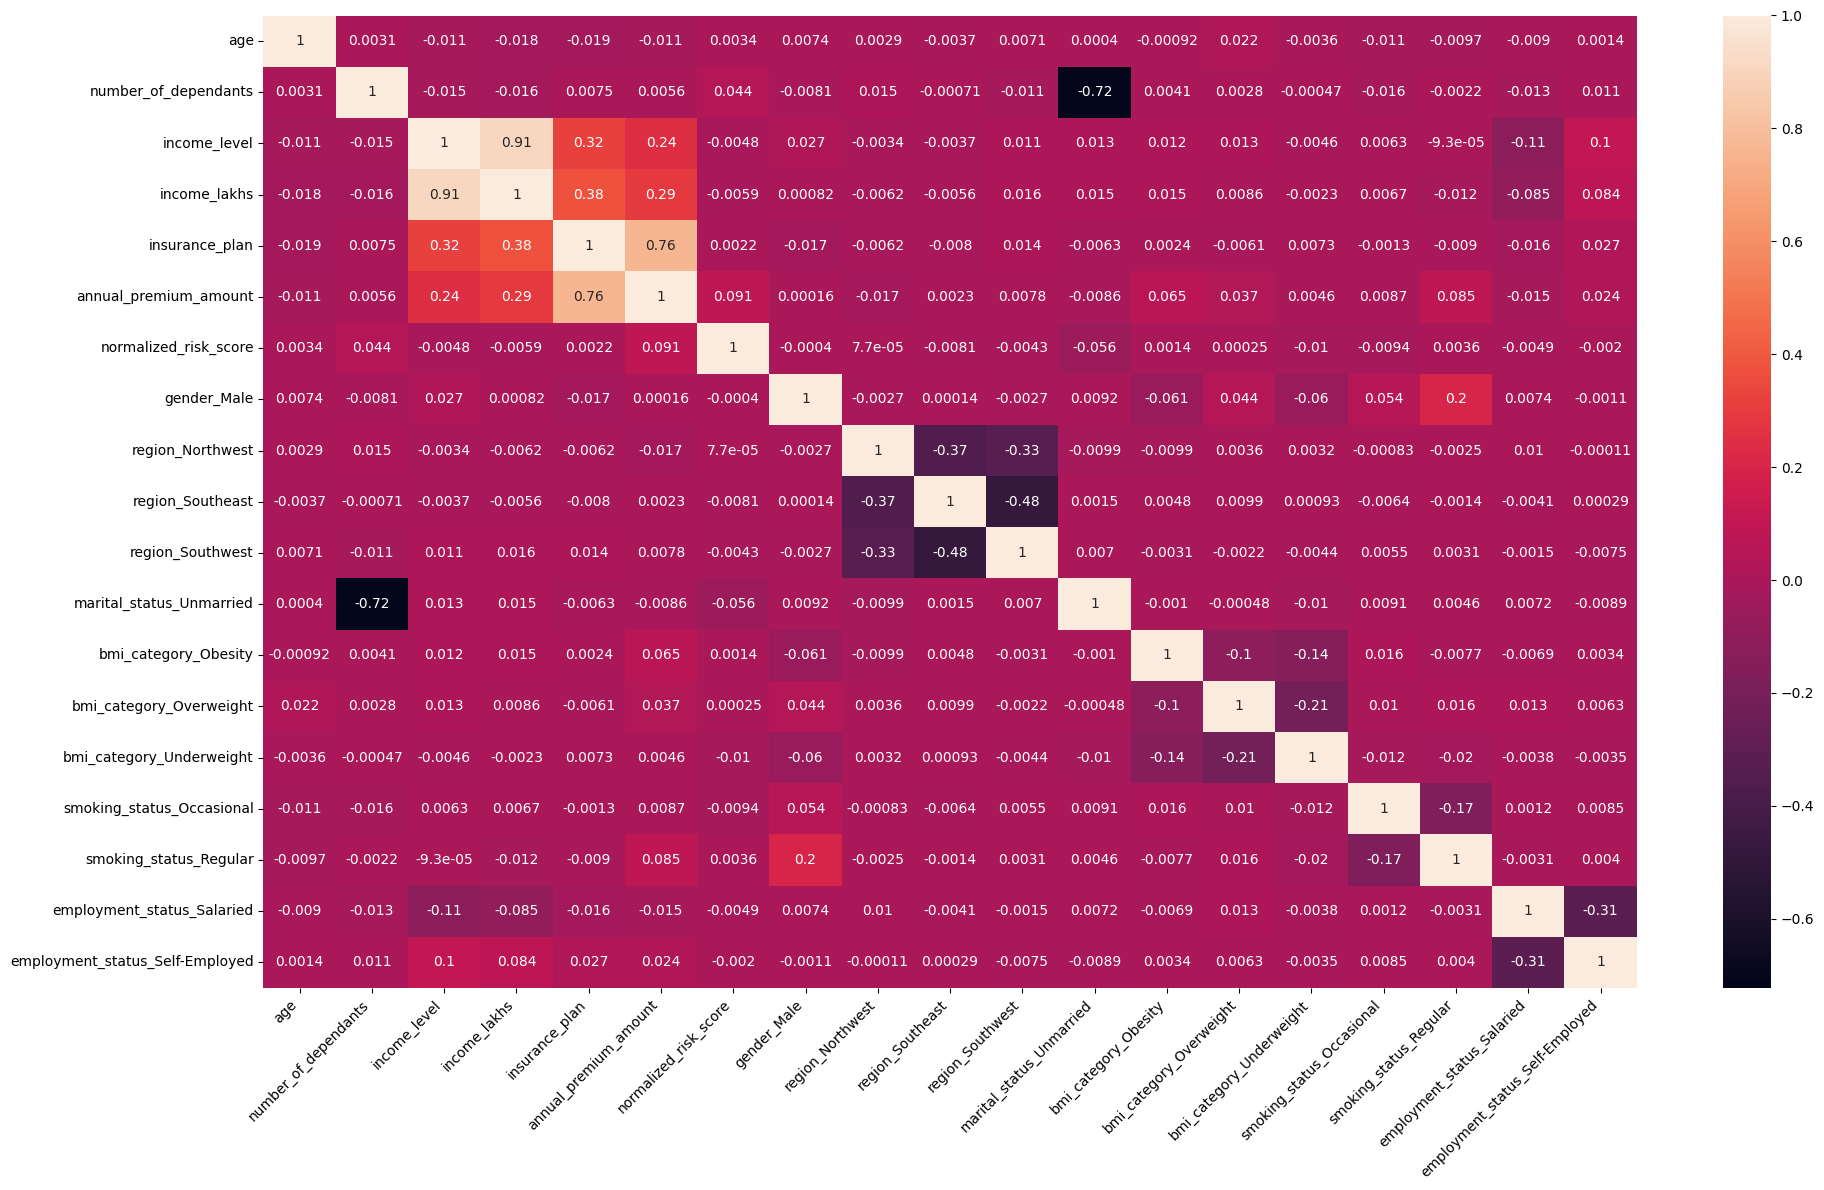

In [115]:
cm = df.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [116]:
df.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'annual_premium_amount', 'normalized_risk_score',
       'gender_Male', 'region_Northwest', 'region_Southeast',
       'region_Southwest', 'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [117]:
X = df.drop('annual_premium_amount', axis=1)
y = df['annual_premium_amount']
cols_to_scale = ['age','income_level','income_lakhs','insurance_plan','number_of_dependants']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,1.000000,1.000000,0.5,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.000000,0.020408,0.5,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,1.000000,0.979592,0.5,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.333333,0.142857,0.0,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.333333,0.132653,0.0,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


In [118]:
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000,20054.000000
mean,0.499145,0.240816,0.356970,0.217005,0.178967,0.092130,0.550364,0.201306,0.346863,0.304578,0.899920,0.063528,0.136531,0.222300,0.086417,0.223497,0.350155,0.149945
std,0.327769,0.312344,0.346809,0.219663,0.299827,0.230059,0.497469,0.400987,0.475984,0.460240,0.300114,0.243917,0.343360,0.415802,0.280985,0.416599,0.477030,0.357027
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142857,0.000000,0.000000,0.051020,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.428571,0.000000,0.333333,0.153061,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.714286,0.333333,0.666667,0.306122,0.500000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Calculating VIF

In [119]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [120]:
calculate_vif(X)

,Column,VIF
0,age,3.142125
1,number_of_dependants,1.860137
2,income_level,12.076228
3,income_lakhs,12.064125
4,insurance_plan,1.586966
5,normalized_risk_score,1.154327
6,gender_Male,2.309901
7,region_Northwest,2.147121
8,region_Southeast,2.968665
9,region_Southwest,2.730084


In [121]:
calculate_vif(X.drop('income_level',axis=1))

,Column,VIF
0,age,3.140709
1,number_of_dependants,1.857617
2,income_lakhs,2.293723
3,insurance_plan,1.581668
4,normalized_risk_score,1.154291
5,gender_Male,2.299671
6,region_Northwest,2.146229
7,region_Southeast,2.967484
8,region_Southwest,2.729448
9,marital_status_Unmarried,7.305480


In [122]:
X_reduced = X.drop('income_level',axis=1)
X_reduced.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,1.000000,0.5,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,0.571429,0.000000,0.020408,0.5,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,0.428571,0.000000,0.979592,0.5,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,1.000000,0.000000,0.142857,0.0,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,0.285714,0.666667,0.132653,0.0,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


#### Model Training

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=10)

print("X train: ",X_train.shape)
print("X test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

X train:  (14037, 17)
X test:  (6017, 17)
y train:  (14037,)
y test:  (6017,)


In [124]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
r2_train = model_lr.score(X_train, y_train)
# y_pred = model_lr.predict(X_test)
r2_test = model_lr.score(X_test, y_test)

r2_test, r2_train

(0.5964252843262741, 0.6048350981759056)

In [125]:
model_lr.intercept_

np.float64(6542.521635489466)

In [126]:
model_lr.coef_

array([ 7.26389744e+01, -1.51679170e+01,  6.04888843e+00,  7.00382876e+03,
        1.03703478e+03, -3.14881122e+01, -8.95715718e+01,  9.05237749e+00,
       -5.03905309e+01, -3.11130924e+01,  7.50869774e+02,  4.32893765e+02,
        1.04140913e+02,  3.03204022e+02,  6.60132731e+02, -2.57407237e+01,
        1.56223624e+01])

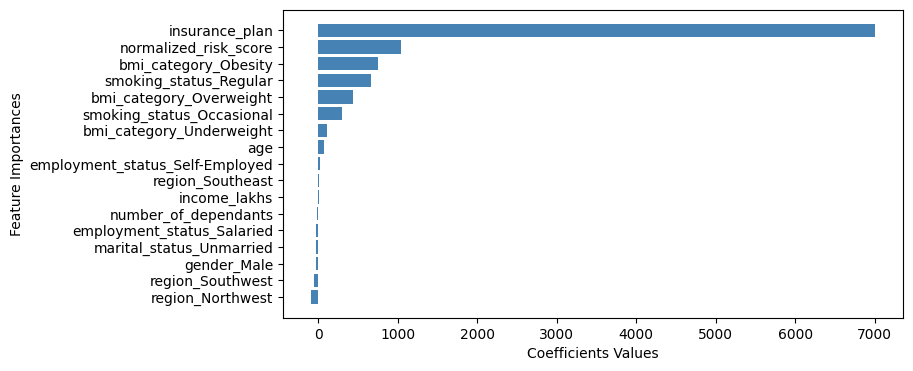

In [127]:
feature_importances = model_lr.coef_
coef_df = pd.DataFrame(feature_importances, index=X_test.columns, columns=['Coefficients'])
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

plt.figure(figsize=(8,4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficients Values')
plt.ylabel('Feature Importances')
plt.show()

In [128]:
model_rg = Ridge()
model_rg.fit(X_train, y_train)
r2_train = model_rg.score(X_train, y_train)
# y_pred = model_rg.predict(X_test)
r2_test = model_rg.score(X_test, y_test)

r2_test, r2_train

(0.5964335620224849, 0.6048346412141938)

In [129]:
from xgboost import XGBRegressor

In [130]:
model_xgb = XGBRegressor()
model_xgb.fit(X_train, y_train)
r2_train = model_xgb.score(X_train, y_train)
y_pred = model_xgb.predict(X_test)
r2_test = model_xgb.score(X_test, y_test)

r2_test, r2_train

(0.5569512248039246, 0.7274904251098633)

In [131]:
mse_xgb = mean_squared_error(y_test, y_pred)
rmse_xgb = np.sqrt(mse_xgb)
print(f"XGBoost Regression ==> MSE: {mse_xgb} RMSE: {rmse_xgb}")

XGBoost Regression ==> MSE: 3363838.25 RMSE: 1834.0769476769506


In [132]:
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20,40,50],
    'learning_rate': [0.01,0.1,0.2],
    'max_depth':[3,4,5]
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2')
random_search.fit(X_train, y_train)
random_search.best_score_

np.float64(0.6017181277275085)

In [133]:
best_model = random_search.best_estimator_

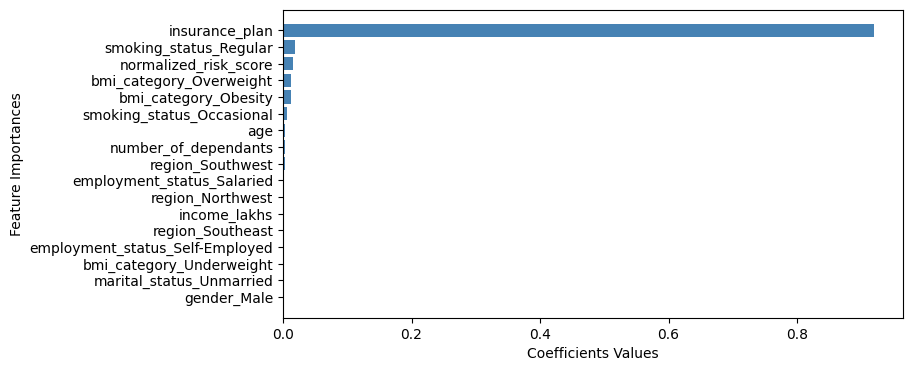

In [134]:
feature_importances = best_model.feature_importances_
coef_df = pd.DataFrame(feature_importances, index=X_test.columns, columns=['Coefficients'])
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

plt.figure(figsize=(8,4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficients Values')
plt.ylabel('Feature Importances')
plt.show()

#### Error Analysis

In [135]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = residuals*100/y_test
results_df = pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residuals,
    'diff_pct':residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
1710,4096,6953.418457,2857.418457,69.761193
11963,4503,6953.418457,2450.418457,54.417465
8719,8332,10758.697266,2426.697266,29.125027
7208,11578,10089.153320,-1488.846680,-12.859273
9416,7045,6611.855469,-433.144531,-6.148255


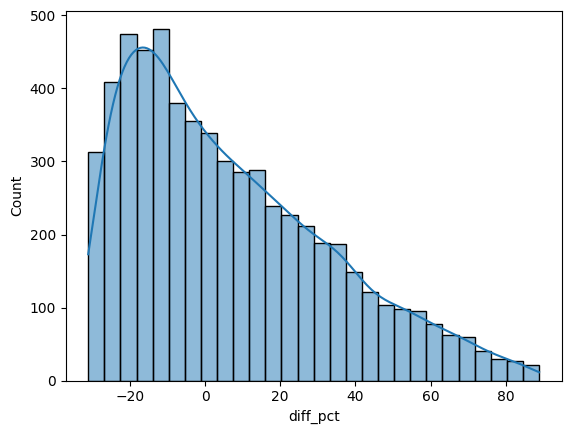

In [136]:
sns.histplot(results_df['diff_pct'],kde=True)
plt.show()

In [137]:
extreme_error_threshold = 10
extreme_results_df = results_df[np.abs(results_df.diff_pct)>extreme_error_threshold]
extreme_results_df.shape


(4422, 4)

In [138]:
extreme_error_pct = extreme_results_df.shape[0]*100/results_df.shape[0]
extreme_error_pct

73.49177330895795

In [139]:
results_df[np.abs(results_df.diff_pct)>50].sort_values('diff_pct', ascending=False)

,actual,predicted,diff,diff_pct
14598,3501,6611.855469,3110.855469,88.856197
10165,3501,6611.855469,3110.855469,88.856197
7299,3505,6611.855469,3106.855469,88.640670
18500,3508,6611.855469,3103.855469,88.479346
17197,3508,6611.855469,3103.855469,88.479346
...,...,...,...,...
1720,4799,7212.455566,2413.455566,50.290802
11007,4402,6611.855469,2209.855469,50.201169
5828,4887,7337.037109,2450.037109,50.133765
18326,4633,6953.418457,2320.418457,50.084577


In [140]:
X_test.index

Index([ 1710, 11963,  8719,  7208,  9416, 15637,  6511, 11179,  7608,  6396,
       ...
       18017, 17253,  5619, 20068,  3065,  2154, 11201, 18574, 17354, 10020],
      dtype='int64', length=6017)

In [141]:
extreme_results_df.index

Index([ 1710, 11963,  8719,  7208, 15637,  6511,  7608,  8942,   395, 18536,
       ...
       14978, 19824, 16023, 18017, 17253, 20068,  3065,  2154, 18574, 10020],
      dtype='int64', length=4422)

In [142]:
extreme_error_df = X_test.loc[extreme_results_df.index]
extreme_error_df.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
1710,0.714286,0.0,0.040816,0.0,0.0,0,0,1,0,1,0,1,0,0,0,0,0
11963,1.000000,0.0,0.051020,0.0,0.0,1,0,1,0,1,0,1,0,0,0,0,0
8719,0.428571,0.0,0.061224,0.5,0.0,1,0,0,0,1,0,0,0,0,1,0,0
7208,0.571429,1.0,0.265306,0.5,0.0,0,0,0,1,0,0,0,0,0,0,0,0
15637,0.000000,0.0,0.244898,0.0,0.0,1,0,0,1,1,0,0,0,0,0,1,0


In [143]:
extreme_error_df['income_level']=-1

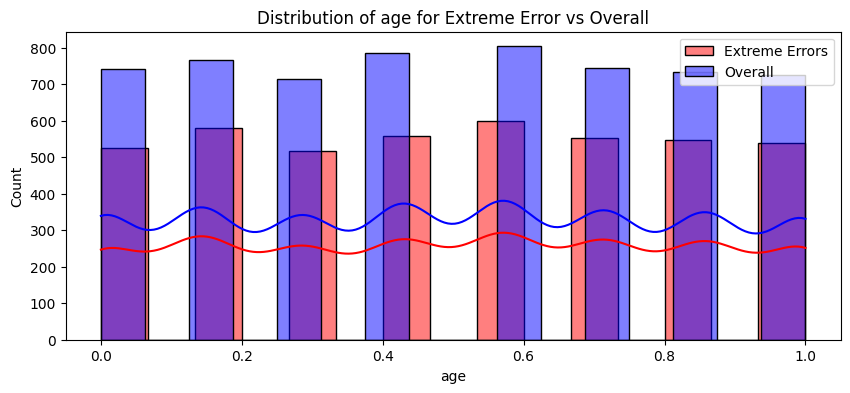

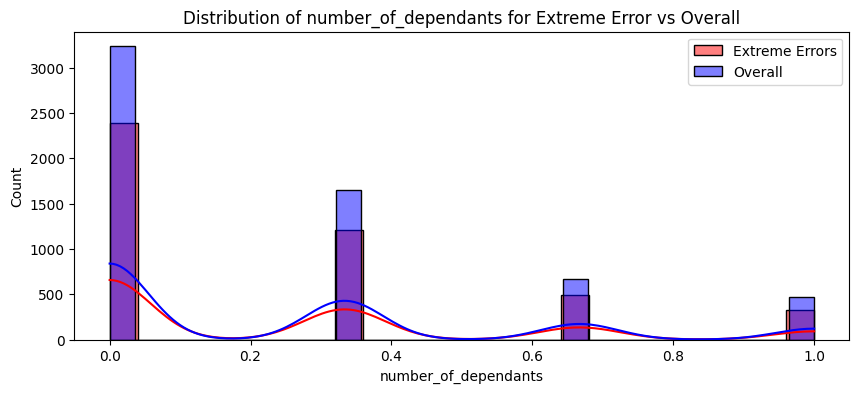

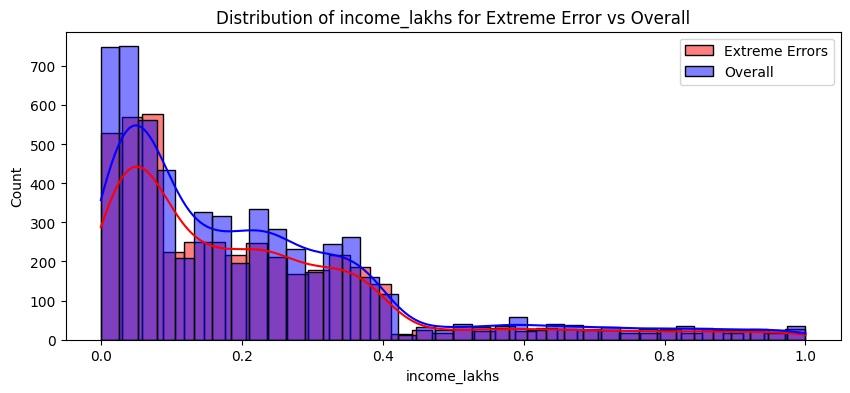

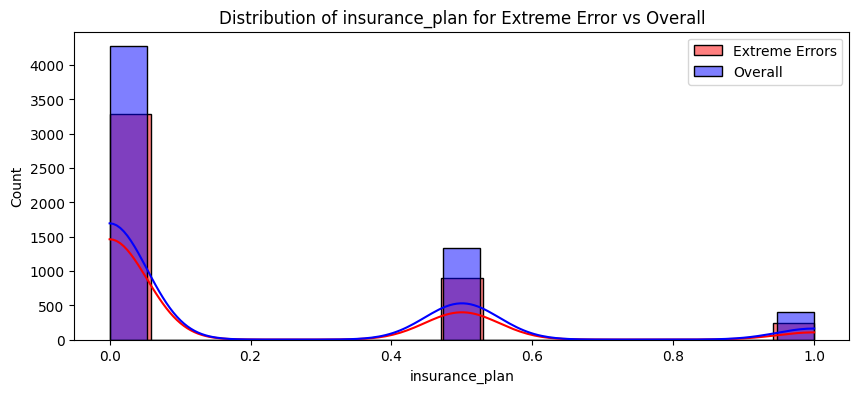

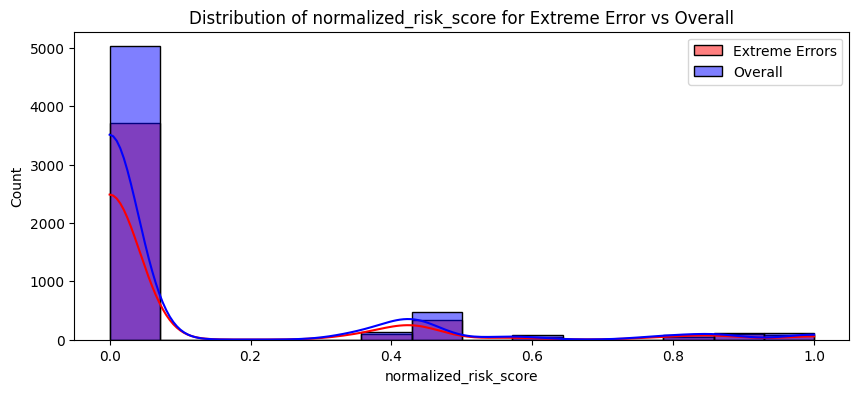

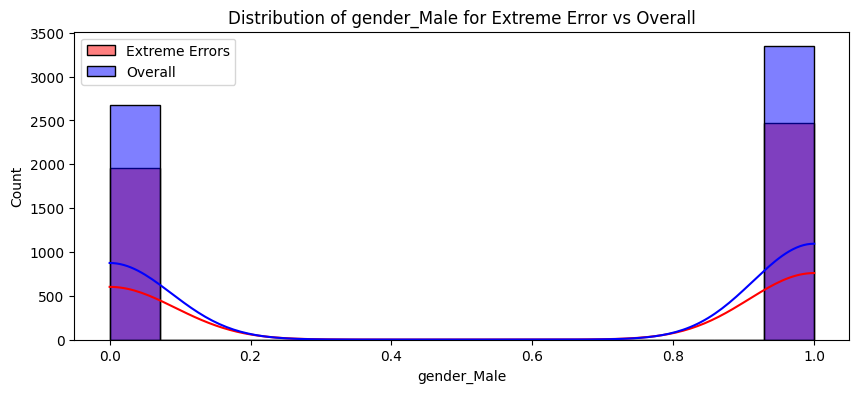

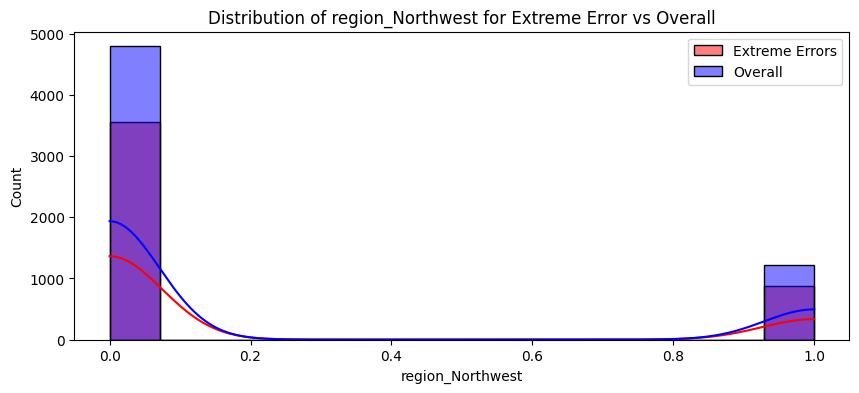

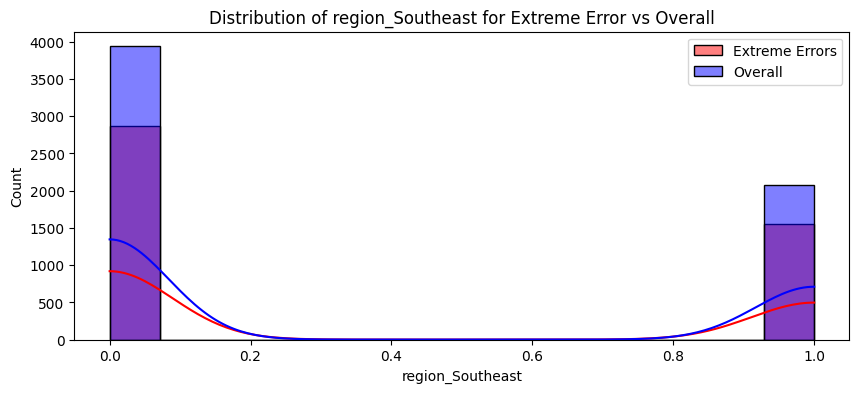

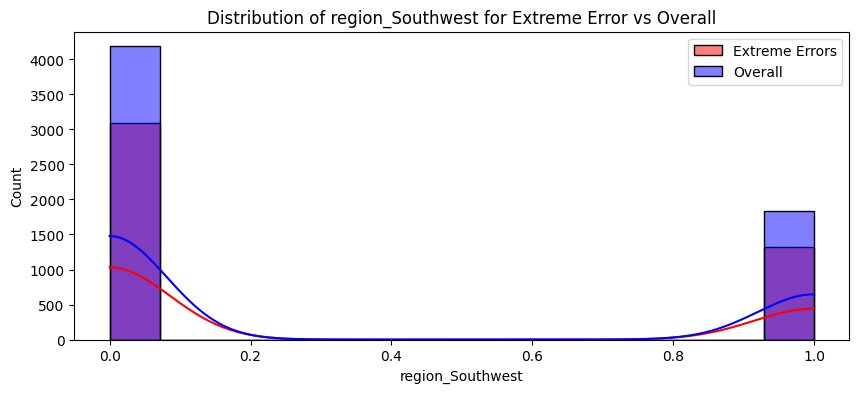

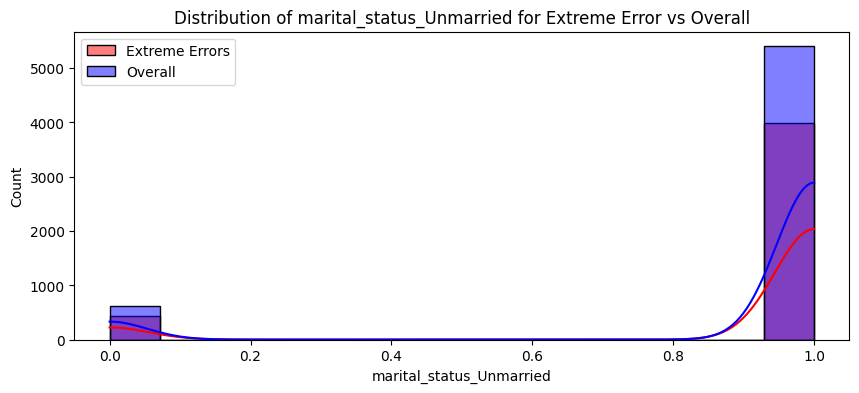

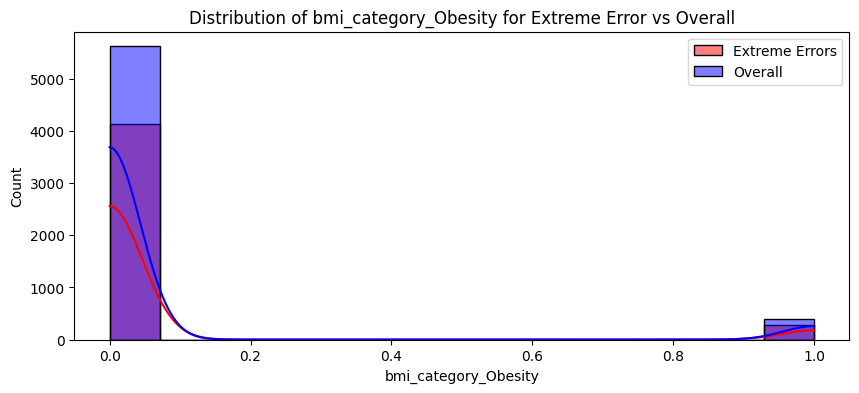

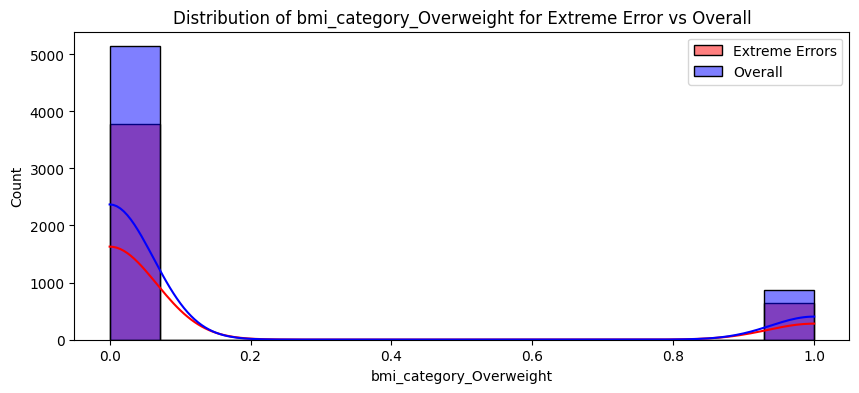

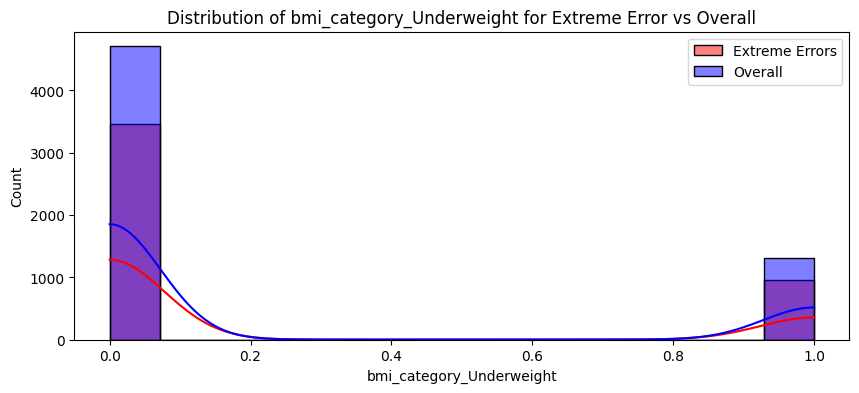

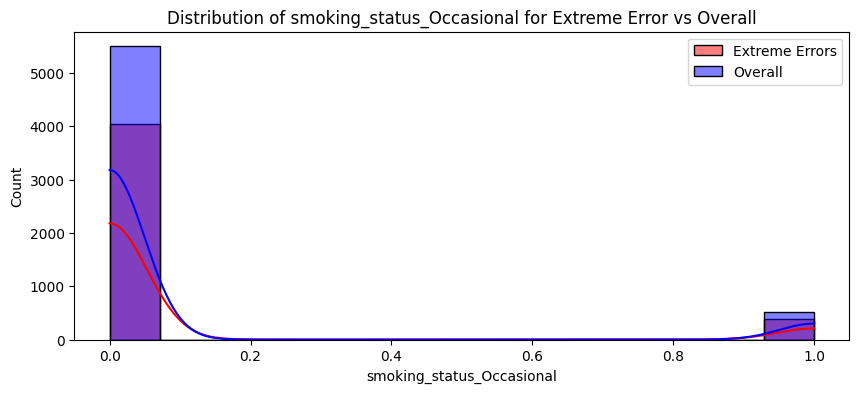

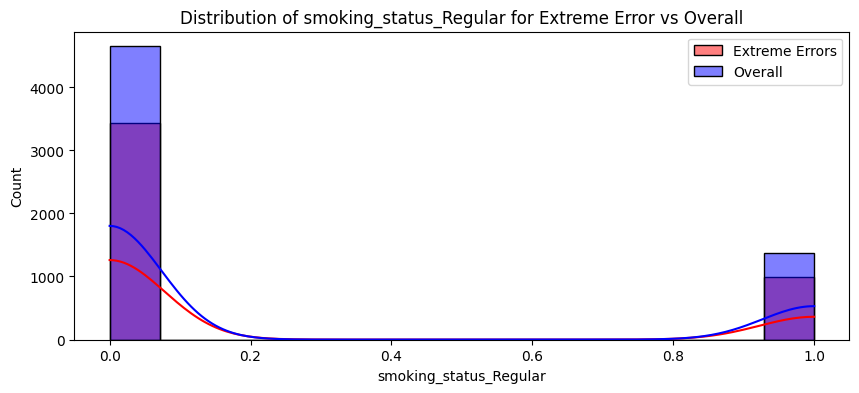

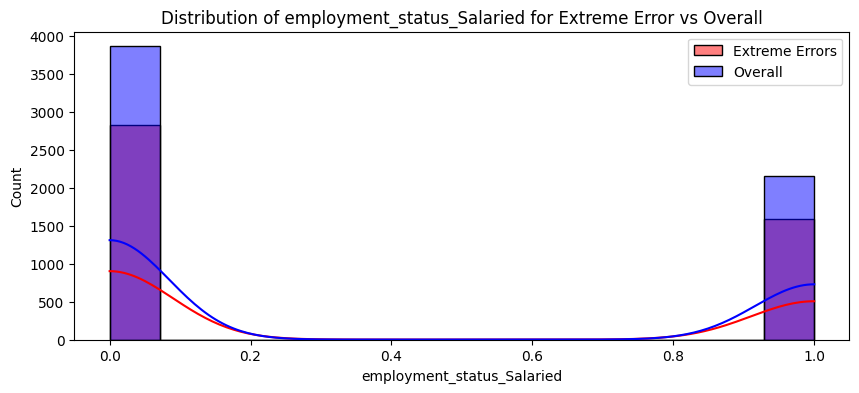

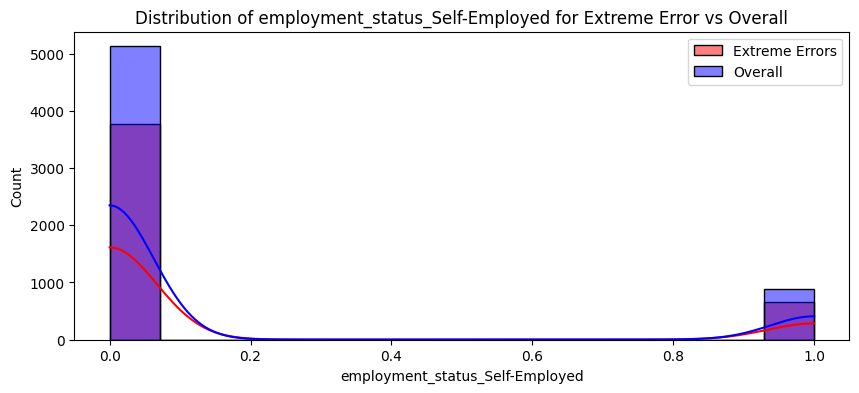

In [144]:
for feature in X_test.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(extreme_error_df[feature],color='red',label='Extreme Errors',kde=True)
    sns.histplot(X_test[feature],color='blue', label='Overall',alpha=0.5,kde=True)
    plt.legend()
    plt.title(f"Distribution of {feature} for Extreme Error vs Overall")
    plt.show()

<Axes: xlabel='age', ylabel='Count'>

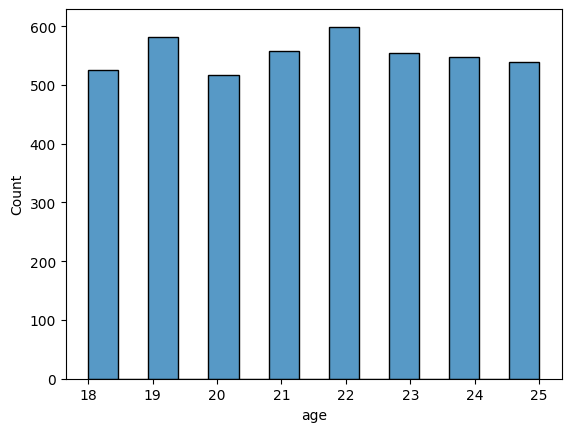

In [145]:
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_error_df[cols_to_scale])
df_reversed
sns.histplot(df_reversed['age'])

In [146]:
df_reversed['age'].quantile(0.99)

np.float64(25.0)